<p> <center><img src="https://datascientest.fr/train/assets/logo_datascientest.png" style="height:200px"> </p>

<hr style="border-width:2px;border-color:#75DFC1">
<center><h1> Analyse et prédiction de la variabilité de la production solaire à partir de données ouvertes de la région PACA </h1></center>
<center><h2> Collecte de nouvelles données </h2></center>
<hr style="border-width:2px;border-color:#75DFC1">


Au début du projet, nous avons collecté les données mises à disposition par RTE dans le dataset **éCO2mix** en nous restreignant aux données définitives ou consolidées. 
Initialement, les années 2013 à 2023 étaient disponibles en `données définitives` et l'année 2024 en `données consolidées`. 

Vers le milieu du projet, RTE a fourni une **version définitive de 2024** et une **version consolidée de 2025**. 

Cependant, **les premiers mois de 2026** sont tout de même disponibles, sous forme de `données temps réel` (non encore consolidées). Ces données `temps réel` sont formatées un peu différemment des précédentes et nécessite un traitement un peu différent (par exemple, la résolution temporelle est de 15 minutes au lieu de 30).

Ce notebook propose une collecte des nouvelles données pour les concaténer aux anciennes.

# I - Collecte des données de RTE


On importe les librairies dont on va avoir besoin pour manipuler nos jeux de données :

In [7]:
# Gestion des chemins
from pathlib import Path

# Importer des librairies usuelles pour traiter des datasets
import pandas as pd
import numpy as np

# Importer une librairie pour traiter des fichiers zip
from zipfile import ZipFile

On peut trouver les nouvelles données brutes sur le site Internet de **RTE** (https://www.rte-france.com/donnees-publications/eco2mix-donnees-temps-reel/telecharger-indicateurs).

On a préalablement téléchargé ces données et on les a placées dans un répertoire de travail dont on stocke le chemin dans une variable `input_datasets`. Les résultats intermédiaires et finaux seront stockés dans `output_datasets`.

In [8]:
# Répertoire des données d'éCO2mix téléchargées
input_path = Path('../../data/local_data/input/')

# Répertoire où seront stockés les résultats temporaires
temp_path = Path('../../data/local_data/temp/')

# Répertoire où seront stockés les résultats finaux
output_path = Path('../../data/local_data/output/')

# Chemin du dataset des communes sélectionnées 
communes = output_path / 'best_communes_geo_energy.csv'

On va extraire l'archive téléchargée qui contient les données des années 2025 et début 2026 :

In [9]:
# Récupération du chemin de l'archive à décompresser
chemin_dataset = input_path / 'eCO2mix_RTE_PACA_En-cours-TR'

# Décompresser l'archive pour récupérer 
with ZipFile(chemin_dataset.parent / (chemin_dataset.name + '.zip'), 'r') as zip_file :
        zip_file.printdir()
        zip_file.extractall(temp_path)
        

File Name                                             Modified             Size
eCO2mix_RTE_PACA_En-cours-TR.xls               2026-04-22 08:36:00      1766560


In [11]:
# Observer les premières lignes :
print("\nJeu de données 2026 :")

## Lire le jeu de données
df_rte = pd.read_csv(temp_path / (chemin_dataset.name + '.xls'), sep='\t', encoding='latin_1')

## Afficher les premières lignes
display(df_rte.head())

## Afficher les dernières lignes
display(df_rte.tail())

## Afficher la taille du dataset
print(f"Nombre de colonnes du jeu de données 2026 : {df_rte.shape[1]}.")



Jeu de données 2026 :


,Périmètre,Nature,Date,Heures,Consommation,Thermique,Nucléaire,Eolien,Solaire,Hydraulique,...,TCH Nucléaire (%),TCO Eolien (%),TCH Eolien (%),TCO Solaire (%),TCH Solaire (%),TCO Hydraulique (%),TCH Hydraulique (%),TCO Bioénergies (%),TCH Bioénergies (%),Unnamed: 67
0,PACA,Données temps réel,2026-02-01,00:00,5501.0,437.0,0.0,15.0,0.0,1392.0,...,ND,0.27,12.40,0.0,0.0,25.30,43.15,4.78,85.95,NaN
1,PACA,Données temps réel,2026-02-01,00:15,5485.0,447.0,0.0,17.0,0.0,1165.0,...,ND,0.31,14.05,0.0,0.0,21.24,36.11,4.79,85.95,NaN
2,PACA,Données temps réel,2026-02-01,00:30,5320.0,445.0,0.0,18.0,0.0,1135.0,...,ND,0.34,14.88,0.0,0.0,21.33,35.18,4.94,85.95,NaN
3,PACA,Données temps réel,2026-02-01,00:45,5301.0,521.0,0.0,18.0,0.0,1076.0,...,ND,0.34,14.88,0.0,0.0,20.30,33.35,4.96,85.95,NaN
4,PACA,Données temps réel,2026-02-01,01:00,5230.0,502.0,0.0,24.0,0.0,1083.0,...,ND,0.46,19.83,0.0,0.0,20.71,33.57,5.03,85.95,NaN


,Périmètre,Nature,Date,Heures,Consommation,Thermique,Nucléaire,Eolien,Solaire,Hydraulique,...,TCH Nucléaire (%),TCO Eolien (%),TCH Eolien (%),TCO Solaire (%),TCH Solaire (%),TCO Hydraulique (%),TCH Hydraulique (%),TCO Bioénergies (%),TCH Bioénergies (%),Unnamed: 67
7772,PACA,Données temps réel,2026-04-22,23:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7773,PACA,Données temps réel,2026-04-22,23:15,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7774,PACA,Données temps réel,2026-04-22,23:30,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7775,PACA,Données temps réel,2026-04-22,23:45,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7776,RTE ne pourra Ãªtre tenu responsable de l'usag...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de colonnes du jeu de données 2026 : 68.


On remarque que ce nouveau dataset présente des mesures toutes les 15 minutes alors que dans nos précédents jeux de données d'éCO2mix les mesures n'avaient lieu que toutes les 30 minutes. Pour conserver la cohérence entre l'ancien et le nouveau jeu de donnée, on va devoir supprimer une mesure sur deux.

Concernant l'année 2026, on remarque que les dernières lignes concernant le jour où les données ont été téléchargées sont manquantes : des lignes ont été créées pour cette journée jusqu'à minuit, mais les dernières sont dans le futur par rapport à l'heure d'extraction, d'où les valeurs manquantes observées.

On va :
- ne garder que les colonnes que nous avions conservées dans le premier jeu de données ;
- supprimer les observations où la variable `TCH Solaire (%)` est absente (ce qui nous permet d'éliminer les observations dans le futur par rapport à l'extraction ainsi que la dernière ligne qui est un disclaimer) ;
- supprimer une ligne sur deux pour avoir la même résolution temporelle que dans le premier jeu de données. 
- vérifier que le fuseau horaire est le fuseau de France Métropolitaine (comme les anciens datasets)
- convertir le cas échéant au fuseau UTC et traiter les données manquantes ou en double à cause des changements d'heures


## A - Sélection des colonnes

In [12]:
# Liste des variables d'éCO2mix retenues dans l'ancien dataset
variables_retenues = ['Date', 'Heures', 
                      'Consommation', 'Solaire', 
                      'TCO Solaire (%)', 'TCH Solaire (%)']

# Vérification de la présence de ces variables dans le nouveau dataset
toutes_presentes = True
for var in variables_retenues :
    if var not in df_rte.columns :
        toutes_presentes = False

print("Les variables précédemment retenues sont-elles toutes présentes dans le nouveau dataset ?", toutes_presentes)


Les variables précédemment retenues sont-elles toutes présentes dans le nouveau dataset ? True


In [13]:
# Les variables étant toutes présentes, on peut procéder à leur extraction
print("Dimensions du dataset avant réduction du nombre de variables :", df_rte.shape)
df_rte = df_rte[variables_retenues]
print("Dimensions du dataset après réduction du nombre de variables :", df_rte.shape)

Dimensions du dataset avant réduction du nombre de variables : (7777, 68)
Dimensions du dataset après réduction du nombre de variables : (7777, 6)


## B - Suppression des observations inutiles

Les observations ne contenant pas la variable `TCH Solaire (%)` ne permettront pas de calculer la variable cible de variation de production : on les retire du dataset.

In [14]:
# On supprime les lignes où la variable TCH Solaire est manquante
df_rte = df_rte.dropna(subset=['TCH Solaire (%)'])

On vérifie s'il reste des valeurs manquantes :

In [15]:
print(df_rte.isna().sum())

Date               0
Heures             0
Consommation       0
Solaire            0
TCO Solaire (%)    0
TCH Solaire (%)    0
dtype: int64


## C - Résolution temporelle

On supprime une observation sur deux pour conserver la même résolution temporelle que précédemment.

In [16]:
display(df_rte.head())

,Date,Heures,Consommation,Solaire,TCO Solaire (%),TCH Solaire (%)
0,2026-02-01,00:00,5501.0,0.0,0.0,0.0
1,2026-02-01,00:15,5485.0,0.0,0.0,0.0
2,2026-02-01,00:30,5320.0,0.0,0.0,0.0
3,2026-02-01,00:45,5301.0,0.0,0.0,0.0
4,2026-02-01,01:00,5230.0,0.0,0.0,0.0


In [17]:
# Les heures qu'on souhaite conserver se terminent par le caractère '0' (les autres par '5')
print("Dimensions du dataset avant suppression des lignes :", df_rte.shape)
df_rte = df_rte.loc[df_rte['Heures'].str.endswith('0')]
print("Dimensions du dataset après suppression des lignes :", df_rte.shape)
display(df_rte.tail())

Dimensions du dataset avant suppression des lignes : (7723, 6)
Dimensions du dataset après suppression des lignes : (3862, 6)


,Date,Heures,Consommation,Solaire,TCO Solaire (%),TCH Solaire (%)
7714,2026-04-22,08:30,3383.0,301.0,8.90,10.69
7716,2026-04-22,09:00,3470.0,362.0,10.43,12.86
7718,2026-04-22,09:30,3455.0,491.0,14.21,17.44
7720,2026-04-22,10:00,3477.0,500.0,14.38,17.76
7722,2026-04-22,10:30,3611.0,564.0,15.62,20.03


## D - Fuseau horaire

RTE ne précise pas le fuseau horaire utilisé pour le dataset. Si le fuseau est le fuseau de France métropolitaine, on observera un décalage d'une heure en plus ou en moins entre le jour avant et suivant un changement d'heure.

Changements d'heure en 2026 (le passage à l'heure d'hiver est dans le futur par rapport à la dernière extraction donc non traitée pour le moment) :
 - passage à l'heure d'été : entre le 28 et le 29 mars
 - passage à l'heure d'hiver : entre le 24 et le 25 octobre


In [18]:
# On importe une librairie de Datavizualisation
import matplotlib.pyplot as plt
%matplotlib inline

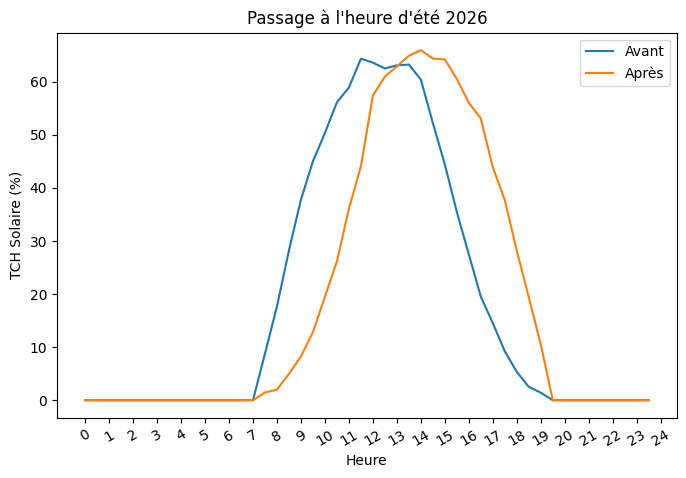

In [19]:
plt.figure(figsize=(8,5))

# On affiche la production d'énergie solaire avant et après le passage à l'heure d'été
plt.plot(df_rte[df_rte['Date'] == '2026-03-28'].Heures, df_rte[df_rte['Date'] == '2026-03-28']['TCH Solaire (%)'], label='Avant')
plt.plot(df_rte[df_rte['Date'] == '2026-03-29'].Heures, df_rte[df_rte['Date'] == '2026-03-29']['TCH Solaire (%)'], label='Après')
plt.xlabel('Heure')
plt.ylabel('TCH Solaire (%)')
# On nettoie les ticks sur l'axe des x car sinon on ne peut rien lire
# On n'affiche que les heures
plt.xticks([2*k for k in range(0, 25)],
          [str(k) for k in range(25)],
          rotation=30)
plt.title("Passage à l'heure d'été 2026")
plt.legend();

On observe bien un changement d'heure : on va convertir notre fuseau horaire au fuseau international UTC pour concaténer nos données avec d'autres sources.

## E - Conversion du fuseau horaire en UTC

Nous venons de voir que nos données de production étaient données en fonction du fuseau horaire de France métropolitaine.

Il y a deux raisons pour lesquelles nous devrions **changer de fuseau horaire** :    
 - Premièrement le fuseau horaire actuel introduit une modification du *décalage entre l'heure solaire et l'heure légale* deux fois par an : cela **risque de perturber** notre modélisation ;

 - Deuxièmement nous allons devoir *aggréger de nouvelles variables explicatives* à notre jeu de données pour pouvoir expliquer notre variable cible. Comme nous interrogerons des **bases internationnales**, il nous faut convertir nos dates et heures en UTC.

On va créer une nouvelle variable `datetime_utc` qui contiendra les mêmes informations que les variables `Date` et `Heures`, mais en heures UTC, de manière à pouvoir aggréger plus facilement d'autres données par la suite, sur la base de cette variable.

In [20]:
# Aggréger la date et l'heure FR dans une nouvelle colonne
df_rte['datetime_fr'] = pd.to_datetime(df_rte['Date'] + ' ' + df_rte['Heures'], format="%Y-%m-%d %H:%M")

# Indiquer que l'heure est celle de Paris
df_rte['datetime_fr'] = df_rte['datetime_fr'].dt.tz_localize("Europe/Paris",
                                                     nonexistent='shift_forward',
                                                     ambiguous=True)
# Convertir en UTC
df_rte['datetime_utc'] = df_rte['datetime_fr'].dt.tz_convert("UTC")


Comme vu pour l'extraction initiale des données, il faut traiter les doublons créés lors du passage à l'heure d'été.

In [21]:
# Voir les duplicatas au moment du passage à l'heure d'été
display(df_rte[df_rte.duplicated(subset=['datetime_utc'])]) # Tous les dulicatas correspondent à des passages à l'heure d'été
print("Nombre de duplicata :", df_rte.duplicated(subset=['datetime_utc']).sum())


,Date,Heures,Consommation,Solaire,TCO Solaire (%),TCH Solaire (%),datetime_fr,datetime_utc
5386,2026-03-29,02:30,4671.0,0.0,0.0,0.0,2026-03-29 03:00:00+02:00,2026-03-29 01:00:00+00:00
5388,2026-03-29,03:00,4621.0,0.0,0.0,0.0,2026-03-29 03:00:00+02:00,2026-03-29 01:00:00+00:00


Nombre de duplicata : 2


In [22]:
# On supprime les duplicatas
df_rte = df_rte.drop_duplicates(subset=['datetime_utc'])
print("Nombre de duplicata restants :", df_rte.duplicated(subset=['datetime_utc']).sum())


Nombre de duplicata restants : 0


Inversement, le passage à l'heure d'hiver créera des données manquantes qu'il nous faudra reconstituer. Pour le moment cela est inutile car dans le futur. 

On laisse toutefois les cellules suivantes en place au cas où l'on voudrait poursuivre le projet.

In [23]:
# Recherche des créneaux manquants

# On commence par faire la liste des créneaux qui devraient être présents dans le jeu de données
# Un créneau toute les 30 minutes entre le premier et le dernier créneau horaire du dataset
totalite_creneaux = pd.date_range(
    start=df_rte['datetime_utc'].iloc[0], 
    end=df_rte['datetime_utc'].iloc[-1], 
    freq='30min')

# Créneaux manquants
print("Créneaux manquants :")
creneaux_manquants = totalite_creneaux.difference(df_rte['datetime_utc'])
print(creneaux_manquants) # Les seuls créneaux manquants correspondent au passage à l'heure d'hiver


Créneaux manquants :
DatetimeIndex([], dtype='datetime64[ns, UTC]', freq='30min')


Les **seuls créneaux manquants** sont ceux dûs aux **passages à l'heure d'hiver**.

On décide de traiter ces créneaux manquants *de la même manière* que ceux de l'heure inexistante au moment du passage à l'heure d'été, c'est à dire qu'on **copie les données de l'heure suivante**.

L'**impact** de ces données synthétique pour notre problématique de production d'énergie solaire est **minime** vu que les changement d'heure ont lieu à un moment où *les panneaux solaires ne produisent pas* d'énergie.

In [24]:
print(df_rte.shape)
df2 = pd.DataFrame(totalite_creneaux, columns=['datetime_utc'])
df_rte = df2.merge(df_rte, how='left', on='datetime_utc')
print(df_rte.shape)
print(f"\n{df_rte.isna().sum()}")
df_rte.sort_values(by='datetime_utc', inplace=True)

for creneau in creneaux_manquants:
    df_rte.loc[df_rte['datetime_utc']==creneau, 'Périmètre':'datetime_fr'] = df_rte.loc[df_rte['datetime_utc']==creneau + pd.Timedelta(hours=1), 'Périmètre':'datetime_fr'].values

print(f"\n{df_rte.isna().sum()}")


(3860, 8)
(3860, 8)

datetime_utc       0
Date               0
Heures             0
Consommation       0
Solaire            0
TCO Solaire (%)    0
TCH Solaire (%)    0
datetime_fr        0
dtype: int64

datetime_utc       0
Date               0
Heures             0
Consommation       0
Solaire            0
TCO Solaire (%)    0
TCH Solaire (%)    0
datetime_fr        0
dtype: int64


On abandonne maintenant les colonnes de dates inutiles pour ne conserver que le **fuseau horaire UTC** :

In [25]:
# On supprime les colonnes 'Date', 'Heures' et 'datetime_fr'
df_rte = df_rte.drop(['Date', 'Heures', 'datetime_fr'], axis=1)


On réinitialise l'index :

In [26]:
# On réinitialise l'index
df_rte.reset_index(drop=True, inplace=True)

display(df_rte.head())
print(df_rte.shape)

,datetime_utc,Consommation,Solaire,TCO Solaire (%),TCH Solaire (%)
0,2026-01-31 23:00:00+00:00,5501.0,0.0,0.0,0.0
1,2026-01-31 23:30:00+00:00,5320.0,0.0,0.0,0.0
2,2026-02-01 00:00:00+00:00,5230.0,0.0,0.0,0.0
3,2026-02-01 00:30:00+00:00,5179.0,0.0,0.0,0.0
4,2026-02-01 01:00:00+00:00,5129.0,0.0,0.0,0.0


(3860, 5)


## F - Normalisation du nom des colonnes

In [27]:
# Normalisation du nom des colonnes (minuscules, pas d'espace, pas de caractères spéciaux autre que '_')
import utilitaires_de_collecte

df_rte = utilitaires_de_collecte.normalize_columns_name(df_rte)
    
print(df_rte.info())
df_rte.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3860 entries, 0 to 3859
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   datetime_utc  3860 non-null   datetime64[ns, UTC]
 1   consommation  3860 non-null   float64            
 2   solaire       3860 non-null   float64            
 3   tco_solaire   3860 non-null   float64            
 4   tch_solaire   3860 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(4)
memory usage: 150.9 KB
None


,datetime_utc,consommation,solaire,tco_solaire,tch_solaire
0,2026-01-31 23:00:00+00:00,5501.0,0.0,0.0,0.0
1,2026-01-31 23:30:00+00:00,5320.0,0.0,0.0,0.0
2,2026-02-01 00:00:00+00:00,5230.0,0.0,0.0,0.0
3,2026-02-01 00:30:00+00:00,5179.0,0.0,0.0,0.0
4,2026-02-01 01:00:00+00:00,5129.0,0.0,0.0,0.0


## F - Enregistrement

On enregistre le résultat obtenu à cette étape avant de poursuivre la collecte de données.

In [28]:
# On enregistre une seconde version de ce dataset production avant ajout d'autres variables
df_rte.to_csv(temp_path / "production_2026.csv", index=False)

# II - Collecte des données astronomiques

Création du dataset qui contiendra les données astronomiques :

In [24]:
# On n'a besoin que des crénaux horaires
df_astro = df_rte[['datetime_utc']].copy()
display(df_astro.head())


,datetime_utc
0,2026-01-31 23:00:00+00:00
1,2026-01-31 23:30:00+00:00
2,2026-02-01 00:00:00+00:00
3,2026-02-01 00:30:00+00:00
4,2026-02-01 01:00:00+00:00


On récupère les coordonnées des cinq points significatifs que l'on a précédemment déterminé.

In [32]:
# Récupération des coordonnées des cinq points significatifs que l'on a précédemment déterminé.
df_communes = pd.read_csv(communes)
display(df_communes.head())
print(df_communes.dtypes)

,cluster_geo,best_commune,code_insee,lat,lon,energie_totale,poids,prefix
0,2,Cruis,4065,44.0845,5.8397,20356525.0,0.22,cru
1,4,Saint-Étienne-le-Laus,5140,44.5075,6.1616,325158.0,0.06,sel
2,0,Saint-Vallier-de-Thiey,6130,43.6994,6.8516,344281.0,0.07,svt
3,1,Bras,83021,43.4723,5.9558,10603661.0,0.29,bra
4,3,Eygalières,13034,43.7638,4.9554,1510927.0,0.36,eyg


cluster_geo         int64
best_commune       object
code_insee          int64
lat               float64
lon               float64
energie_totale    float64
poids             float64
prefix             object
dtype: object


In [26]:
# On importe les librairies dont on a besoin
from pysolar.solar import *
import datetime

In [27]:
# On parcours les villes
for ville in df_communes['prefix'] :
    print(ville + "...")
    latitude = df_communes.loc[df_communes['prefix']==ville, 'lat'].iloc[0]
    longitude = df_communes.loc[df_communes['prefix']==ville, 'lon'].iloc[0]

    # On crée une nouvelle colonne pour la ville pour l'azimuth
    print("\tAzimuth...")
    df_astro[ville + '_azimuth'] = df_astro['datetime_utc'].apply(lambda date : get_azimuth(latitude, longitude, date))
    print("\t\tOK")

    # On crée une nouvelle colonne pour la ville pour l'altitude
    print("\tAltitude...")
    df_astro[ville + '_altitude'] = df_astro['datetime_utc'].apply(lambda date : get_altitude(latitude, longitude, date))
    print("\t\tOK")

    print(ville + "-> OK\n")
    

cru...
	Azimuth...
		OK
	Altitude...
		OK
cru-> OK

sel...
	Azimuth...
		OK
	Altitude...
		OK
sel-> OK

svt...
	Azimuth...
		OK
	Altitude...
		OK
svt-> OK

bra...
	Azimuth...
		OK
	Altitude...
		OK
bra-> OK

eyg...
	Azimuth...
		OK
	Altitude...
		OK
eyg-> OK



In [28]:
display(df_astro.head(10))

,datetime_utc,cru_azimuth,cru_altitude,sel_azimuth,sel_altitude,svt_azimuth,svt_altitude,bra_azimuth,bra_altitude,eyg_azimuth,eyg_altitude
0,2026-01-31 23:00:00+00:00,334.629617,-61.088487,335.551224,-60.801876,336.254693,-61.741821,334.365522,-61.677121,332.724909,-61.093503
1,2026-01-31 23:30:00+00:00,349.473625,-62.749074,350.278452,-62.373162,351.461393,-63.249634,349.496297,-63.366279,347.518861,-62.936315
2,2026-02-01 00:00:00+00:00,5.216025,-62.993831,5.807555,-62.550664,7.432782,-63.296272,5.576685,-63.595424,3.394087,-63.361445
3,2026-02-01 00:30:00+00:00,20.492728,-61.784538,20.839841,-61.307456,22.725069,-61.874025,21.130805,-62.327008,18.953567,-62.301369
4,2026-02-01 01:00:00+00:00,34.192097,-59.297476,34.337259,-58.818184,36.267951,-59.191374,34.980254,-59.753903,32.976466,-59.916951
5,2026-02-01 01:30:00+00:00,45.901416,-55.820588,45.916718,-55.360795,47.745520,-55.552297,46.723939,-56.182836,44.962082,-56.499374
6,2026-02-01 02:00:00+00:00,55.756510,-51.636486,55.705720,-51.207911,57.365216,-51.240175,56.541548,-51.907891,55.017863,-52.342823
7,2026-02-01 02:30:00+00:00,64.111266,-46.969104,64.038510,-46.576964,65.512453,-46.473115,64.824110,-47.157338,63.505020,-47.682156
8,2026-02-01 03:00:00+00:00,71.332587,-41.980679,71.265179,-41.626823,72.561569,-41.406701,71.960564,-42.093888,70.807248,-42.687174
9,2026-02-01 03:30:00+00:00,77.728215,-36.786281,77.682246,-36.471097,78.817988,-36.150558,78.269685,-36.831584,77.247330,-37.477539


In [29]:
# On enregistre ce dataset contenant les données de production et les données astronomiques avant ajout d'autres variables
df_astro.to_csv(temp_path / "astronomie_2026.csv", index=False)


# III - Collecte des données athmosphériques

In [30]:
# On importe les librairies dont on a besoin pour accéder aux données
import yaml
import os
import cdsapi
import time

Création du dataset qui contiendra les données athmosphériques :

In [31]:
# On n'a besoin que des crénaux horaires
df_athmo = df_rte[['datetime_utc']].copy()
display(df_athmo.head())


,datetime_utc
0,2026-01-31 23:00:00+00:00
1,2026-01-31 23:30:00+00:00
2,2026-02-01 00:00:00+00:00
3,2026-02-01 00:30:00+00:00
4,2026-02-01 01:00:00+00:00


In [32]:
# URL de l'API
url = "https://ads.atmosphere.copernicus.eu/api"

# API Token
with open(input_path / 'cams_access', 'r') as f:
    key = f.read().splitlines()[0] # On lit la première ligne du fichier qui contient une clé


In [33]:
def retrieve_ghi (latitude, longitude, date_debut, date_fin, base_chemin) :
    # On crée le client de l'API
    client = cdsapi.Client(url=url, key=key)
    
    # Nom du jeu de données qui nous intéresse
    dataset = "cams-solar-radiation-timeseries"
    
    # Formulation de la requête
    requete = {"sky_type": "observed_cloud",
               "location": {"longitude": longitude, "latitude": latitude},
               "altitude": ["0"],
               "date": [date_debut + "/" + date_fin],
               "time_step": "15minute", # '30minute' n'existe pas on passe directement à un intervalle d'une heure
               "time_reference": "universal_time",
               "data_format": "csv"}
    
    target = base_chemin.parent / (base_chemin.name + "_" + date_debut + "_" + date_fin + ".csv")
    
    # Envoi de la requête
    fname = client.retrieve(dataset, requete, target)

In [36]:
# On détermine la plage de dates à requêter
# En heures UTC le dataset de départ commence le 31 décembre 2019 et se termine le 31 décembre 2024

date_debut = df_athmo.loc[0,'datetime_utc'].strftime('%Y-%m-%d')
date_fin = df_athmo.loc[df_athmo.shape[0]-1,'datetime_utc'].strftime('%Y-%m-%d')

print("Date de début :", date_debut)
print("Date de fin :", date_fin)

Date de début : 2026-01-31
Date de fin : 2026-04-22


In [36]:
# On interroge l'API pour récupérer les données CAMS de chaque ville
# Pour chaque ville
for ville in df_communes['prefix'] :
    # On affiche où on en est rendu dans les villes
    print(ville + "...")
    
    # Le chemin de base du dataset temporaire sera :
    base_chemin = temp_path / ("cams_" + ville) # La fonction de récupération ajoutera les dates et l'extension

    latitude = df_communes.loc[df_communes['prefix']==ville, 'lat'].iloc[0]
    longitude = df_communes.loc[df_communes['prefix']==ville, 'lon'].iloc[0]
    
    # Envoi de la requete
    retrieve_ghi(
        latitude, longitude,
        date_debut, date_fin,
        base_chemin)
    
    # On indique que la requete est terminée
    print("Ok pour", ville, '\n')
    
    # On patiente avant la requête suivante
    time.sleep(10)


cru...


2026-04-22 11:03:12,174 INFO Request ID is 8dfd66fb-fdbb-435f-9483-3725b8bd6a42
2026-04-22 11:03:12,269 INFO status has been updated to accepted
2026-04-22 11:03:33,547 INFO status has been updated to running
2026-04-22 11:03:45,010 INFO status has been updated to successful


Ok pour cru 

sel...


2026-04-22 11:03:56,483 INFO Request ID is 153c5d24-30d1-46ea-a3b5-31eab4822b28
2026-04-22 11:03:56,564 INFO status has been updated to accepted
2026-04-22 11:04:10,248 INFO status has been updated to running
2026-04-22 11:04:17,931 INFO status has been updated to successful


Ok pour sel 

svt...


...

Ok pour svt 

bra...


2026-04-22 11:05:14,894 INFO Request ID is df7d3f35-9cdf-4b40-8c07-5d3a524ae0a7
2026-04-22 11:05:14,954 INFO status has been updated to accepted
2026-04-22 11:05:36,165 INFO status has been updated to running
2026-04-22 11:05:47,645 INFO status has been updated to successful


Ok pour bra 

eyg...


2026-04-22 11:05:58,968 INFO Request ID is 6949d521-4bde-42df-9d95-96f800bf437a
2026-04-22 11:05:59,362 INFO status has been updated to accepted
2026-04-22 11:06:20,653 INFO status has been updated to running
2026-04-22 11:06:34,972 INFO status has been updated to successful


Ok pour eyg 



In [37]:
# On crée une fonction lambda pour obtenir la date au bon format
# (on conserve la borne de début de l'intervalle de temps)
f = lambda x: pd.to_datetime(x.split('/')[0]).tz_localize("UTC")

In [38]:
# On charge les dataset sous forme de DataFrame pour pouvoir les traiter

# On crée un dictionnaire dont les clés seront les préfixes des villes
# et les valeurs les datasets collectés
all_cams = {}

# Pour chaque ville
for ville in df_communes['prefix'] :
    # On affiche où on en est rendu dans les villes
    print(ville + "...")
    
    # Lire les fichiers
    df = pd.read_csv(
        temp_path / ('cams_' + ville + '_' + date_debut + '_' + date_fin + '.csv'),
        sep=';', 
        header=42,
        converters={'# Observation period': f})
    
    # Enregistrer dans all_cams
    all_cams[ville] = df
    
    print(f"{ville} => OK\n")

cru...
cru => OK

sel...
sel => OK

svt...
svt => OK

bra...
bra => OK

eyg...
eyg => OK



In [39]:
display(all_cams['cru'].head())

,# Observation period,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,Reliability
0,2026-01-31 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2026-01-31 00:15:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2026-01-31 00:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2026-01-31 00:45:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2026-01-31 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


A ce stade, nous avons des données athmosphériques avec une résolution temporelle de **15 minutes**.

Cependant, le jeu de données dans lequel nous souhaitons ajouter ces données athmosphériques a une résolution temporelle de **30 minutes**.

Or les données que nous avons collectées concernant l'athmosphères sont toutes cumulatives (à l'exception de la fiabilité `Reliability`) : pour avoir les données pour 30 minutes nous devons maintenant sommer les lignes deux à deux.

Pour que la variable `Reliability` reste pertinente, on sa remplace par la moyenne entre le temp *t* et le temp *t-1*.

In [40]:
# On parcours l'ensemble des datasets
for df_cams in all_cams.values():
    # Les colonnes à sommer vont de la deuxième à l'avant dernière (index 1 à -1)

    # On sélectionne les heures +15min et +45min (toutes les lignes impaires)
    df_impair = df_cams.iloc[1:-1:2, 1:]
    
    # On sélectionne les heures +0min et +30min (toutes les lignes paires)
    # La première ligne n'est pas traitée et importe peu car a lieu en pleine nuit quand il n'y a pas de soleil
    df_pair = df_cams.iloc[2::2, 1:]

    # On modifie l'index de df_impair pour pouvoir le sommer à df_pair
    df_impair.set_index(df_pair.index, inplace=True)

    # On met à jour le dataset avec les valeurs sommées
    df_cams.iloc[2::2, 1:] = df_pair.add(df_impair)

    # On divise par deux la variable 'Reliability' (dernière colonne) pour avoir sa moyenne
    df_cams.iloc[2::2, -1] /= 2


In [41]:
display(all_cams['cru'].head())

,# Observation period,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,Reliability
0,2026-01-31 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2026-01-31 00:15:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2026-01-31 00:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2026-01-31 00:45:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2026-01-31 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [42]:
# renomme les variables des datasets
for ville, df_cams in all_cams.items() :
    mon_dico = {'# Observation period' : 'datetime_utc',
                'TOA' : ville + '_toa',
                'Clear sky GHI' : ville + '_clear_sky_ghi',
                'Clear sky BHI' : ville + '_clear_sky_bhi',
                'Clear sky DHI' : ville + '_clear_sky_dhi',
                'Clear sky BNI' : ville + '_clear_sky_bni',
                'GHI' : ville + '_ghi',
                'BHI' : ville + '_bhi',
                'DHI' : ville + '_dhi',
                'BNI' : ville + '_bni',
                'Reliability' : ville + '_reliability'}
    df_cams.rename(mon_dico, axis=1, inplace=True)


In [43]:
display(all_cams['eyg'].head())

,datetime_utc,eyg_toa,eyg_clear_sky_ghi,eyg_clear_sky_bhi,eyg_clear_sky_dhi,eyg_clear_sky_bni,eyg_ghi,eyg_bhi,eyg_dhi,eyg_bni,eyg_reliability
0,2026-01-31 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2026-01-31 00:15:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2026-01-31 00:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2026-01-31 00:45:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2026-01-31 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


On fusionne les datasets en se basant sur la variable datetime_utc qui contient la date et l'heure des observations :

In [44]:
for df_cams in all_cams.values():
    df_athmo = df_athmo.merge(right=df_cams, on='datetime_utc', how='left')

In [45]:
print(df_athmo.shape)
display(df_athmo.head())

(3860, 51)


,datetime_utc,cru_toa,cru_clear_sky_ghi,cru_clear_sky_bhi,cru_clear_sky_dhi,cru_clear_sky_bni,cru_ghi,cru_bhi,cru_dhi,cru_bni,...,eyg_toa,eyg_clear_sky_ghi,eyg_clear_sky_bhi,eyg_clear_sky_dhi,eyg_clear_sky_bni,eyg_ghi,eyg_bhi,eyg_dhi,eyg_bni,eyg_reliability
0,2026-01-31 23:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2026-01-31 23:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2026-02-01 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2026-02-01 00:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2026-02-01 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [47]:
# On enregistre ce dataset contenant les données de production, astronomiques et météo partielle avant ajout d'autres variables
df_athmo.to_csv(temp_path / "athmosphere_2026.csv", index=False)


# IV - Collecte des données météorologiques

Création du dataset qui contiendra les données athmosphériques :

In [42]:
# On n'a besoin que des crénaux horaires
df_meteo = df_rte[['datetime_utc']].copy()
display(df_meteo.head())


,datetime_utc
0,2026-01-31 23:00:00+00:00
1,2026-01-31 23:30:00+00:00
2,2026-02-01 00:00:00+00:00
3,2026-02-01 00:30:00+00:00
4,2026-02-01 01:00:00+00:00


In [43]:
def retrieve_nasa (latitude, longitude, date_debut, date_fin, base_chemin) :
    # On formatte nos dates pour qu'elles aient la forme voulue par l'API (yyyymmdd)
    debut = "".join([n for n in date_debut if n != '-'])
    fin = "".join([n for n in date_fin if n != '-'])

    # On construit l'URL de la requete à l'API
    url = "https://power.larc.nasa.gov/api/temporal/hourly/point?start=" + str(debut) + '&end=' + str(fin)
    url += '&latitude=' + str(latitude)+'&longitude=' + str(longitude) + "&community=re"
    url += "&parameters=T2M,WS2M,CLOUD_AMT,RH2M"
    url += "&format=csv&units=metric&header=true&time-standard=utc"

    # Signification des paramètres :
    # T2M : Temperature at 2 Meters
    # RH2M : Relative Humidity at 2 Meters
    # WS2M : Wind Speed at 2 Meters
    # ALLSKY_SFC_LW_DWN : All Sky Surface Longwave Downward Irradiance

    # On lit directement le CSV depuis l'API
    df = pd.read_csv(url, skiprows=12)

    # Créer datetime correct en UTC (NASA POWER fournit YEAR, MO, DY, HR)
    df["datetime_utc"] = pd.to_datetime({"year":  df["YEAR"],
                                         "month": df["MO"],
                                         "day":   df["DY"],
                                         "hour":  df["HR"]},
                                        utc=True)

    # Renommer les colonnes en français
    df = df.rename(columns={'T2M': 'temperature',
                            'WS2M': 'vitesse_vent',
                            'CLOUD_AMT': 'nebulosite',
                            'RH2M' : "humidite"})

    # Définir datetime_utc comme index
    df = df.set_index("datetime_utc").sort_index()

    # Remplacer les valeurs manquantes (-999) par np.nan pour qu'on puisse les identifier
    df = df.replace(-999.00, np.nan)

    # Rééchantillonner toutes les 30 minutes et interpoler
    df = df.drop(columns=['YEAR', 'MO', 'DY', 'HR']).resample("30min").interpolate(numeric_only=True)
    df = df.reset_index()

    # On enregistre le dataset
    target = base_chemin.parent / (base_chemin.name + "_" + date_debut + "_" + date_fin + ".csv")
    df.to_csv(target, index=False)
    

In [44]:
# On interroge l'API pour récupérer les données NASA de chaque ville
# Pour chaque ville
for ville in df_communes['prefix'] :
    # On affiche où on en est rendu dans les villes
    print(ville + "...")

    # Le chemin de base du dataset temporaire sera :
    base_chemin = temp_path / ("nasa_" + ville) # La fonction de récupération ajoutera les dates et l'extension

    latitude = df_communes.loc[df_communes['prefix']==ville, 'lat'].iloc[0]
    longitude = df_communes.loc[df_communes['prefix']==ville, 'lon'].iloc[0]
    
    # Envoi de la requete
    retrieve_nasa(latitude, longitude,
                  date_debut, date_fin,
                  base_chemin)

    # On indique que la requete est terminée
    print("Ok pour", ville, '\n')
    

cru...
Ok pour cru 

sel...
Ok pour sel 

svt...
Ok pour svt 

bra...
Ok pour bra 

eyg...
Ok pour eyg 



In [49]:
test = pd.read_csv(temp_path / 'test_bra_nasa.csv')
display(test.loc[(test['MO'] == 2) & (test['DY'] == 1)])

,Unnamed: 0,YEAR,MO,DY,HR,T2M,WS2M,CLOUD_AMT,RH2M
24,24,2026,2,1,0,3.20,2.55,-999.0,97.37
25,25,2026,2,1,1,2.87,2.65,-999.0,98.88
26,26,2026,2,1,2,2.63,2.71,-999.0,99.54
27,27,2026,2,1,3,2.34,2.57,-999.0,100.00
28,28,2026,2,1,4,2.05,2.29,-999.0,100.00
29,29,2026,2,1,5,2.00,1.81,-999.0,100.00
30,30,2026,2,1,6,2.60,1.47,-999.0,98.38
31,31,2026,2,1,7,5.03,1.15,-999.0,86.45
32,32,2026,2,1,8,8.35,0.99,-999.0,73.57
33,33,2026,2,1,9,10.47,0.57,-999.0,63.44


Aggrégation des nouvelles données collectées dans un dictionnaire ayant pour clé le sigle correspondant au point d'intérêt du dataset :


In [40]:
# On crée un dictionnaire dont les clés seront les préfixes des villes
# et les valeurs les datasets collectés
all_nasa = {}

# Pour chaque ville
for ville in df_communes['prefix'] :
    # On affiche où on en est rendu dans les villes
    print(ville + "...")
    
    # Lire les fichiers
    df = pd.read_csv(
        temp_path / ('nasa_' + ville + '_' + date_debut + '_' + date_fin + '.csv'),
        parse_dates=['datetime_utc'])
    
    # Enregistrer dans all_cams
    all_nasa[ville] = df
    
    print(f"{ville} => OK\n")
    

cru...
cru => OK

sel...
sel => OK

svt...
svt => OK

bra...
bra => OK

eyg...
eyg => OK



On affiche l'ensemble des datasets chargés :

In [41]:
for df in all_nasa.values():
    display(df.head())

,datetime_utc,temperature,vitesse_vent,nebulosite,humidite
0,2026-01-31 00:00:00+00:00,1.64,1.43,NaN,86.210
1,2026-01-31 00:30:00+00:00,1.62,1.49,NaN,84.595
2,2026-01-31 01:00:00+00:00,1.60,1.55,NaN,82.980
3,2026-01-31 01:30:00+00:00,1.57,1.59,NaN,82.065
4,2026-01-31 02:00:00+00:00,1.54,1.63,NaN,81.150


,datetime_utc,temperature,vitesse_vent,nebulosite,humidite
0,2026-01-31 00:00:00+00:00,-4.870,1.12,NaN,81.68
1,2026-01-31 00:30:00+00:00,-5.110,1.17,NaN,81.82
2,2026-01-31 01:00:00+00:00,-5.350,1.22,NaN,81.96
3,2026-01-31 01:30:00+00:00,-5.495,1.23,NaN,81.74
4,2026-01-31 02:00:00+00:00,-5.640,1.24,NaN,81.52


,datetime_utc,temperature,vitesse_vent,nebulosite,humidite
0,2026-01-31 00:00:00+00:00,6.79,2.420,NaN,89.600
1,2026-01-31 00:30:00+00:00,6.84,2.790,NaN,93.005
2,2026-01-31 01:00:00+00:00,6.89,3.160,NaN,96.410
3,2026-01-31 01:30:00+00:00,7.00,3.515,NaN,97.125
4,2026-01-31 02:00:00+00:00,7.11,3.870,NaN,97.840


,datetime_utc,temperature,vitesse_vent,nebulosite,humidite
0,2026-01-31 00:00:00+00:00,4.24,1.490,NaN,85.550
1,2026-01-31 00:30:00+00:00,4.34,1.690,NaN,87.005
2,2026-01-31 01:00:00+00:00,4.44,1.890,NaN,88.460
3,2026-01-31 01:30:00+00:00,4.69,2.215,NaN,91.465
4,2026-01-31 02:00:00+00:00,4.94,2.540,NaN,94.470


,datetime_utc,temperature,vitesse_vent,nebulosite,humidite
0,2026-01-31 00:00:00+00:00,5.120,1.960,NaN,84.78
1,2026-01-31 00:30:00+00:00,5.010,1.975,NaN,82.21
2,2026-01-31 01:00:00+00:00,4.900,1.990,NaN,79.64
3,2026-01-31 01:30:00+00:00,4.815,1.910,NaN,77.94
4,2026-01-31 02:00:00+00:00,4.730,1.830,NaN,76.24


On renomme les variables des datasets (à l'exeption de la variable datetime_utc qui servira à la fusion) en les faisants débuter par le sigle du point d'intérêt correspondant :

In [53]:
# On renomme les colonnes des différents datasets pour qu'elles comprennent le nom de la ville
for ville, df in all_nasa.items() :
    mon_dico = {'temperature' : ville + '_temperature',
                'vitesse_vent' : ville + '_vitesse_vent',
                'nebulosite' : ville +'_nebulosite',
                'humidite' : ville + '_humidite'}
    df.rename(mon_dico, axis=1, inplace=True)

for df in all_nasa.values():
    display(df.head())

,datetime_utc,cru_temperature,cru_vitesse_vent,cru_nebulosite,cru_humidite
0,2026-01-31 00:00:00+00:00,1.64,1.43,NaN,86.210
1,2026-01-31 00:30:00+00:00,1.62,1.49,NaN,84.595
2,2026-01-31 01:00:00+00:00,1.60,1.55,NaN,82.980
3,2026-01-31 01:30:00+00:00,1.57,1.59,NaN,82.065
4,2026-01-31 02:00:00+00:00,1.54,1.63,NaN,81.150


,datetime_utc,sel_temperature,sel_vitesse_vent,sel_nebulosite,sel_humidite
0,2026-01-31 00:00:00+00:00,-4.870,1.12,NaN,81.68
1,2026-01-31 00:30:00+00:00,-5.110,1.17,NaN,81.82
2,2026-01-31 01:00:00+00:00,-5.350,1.22,NaN,81.96
3,2026-01-31 01:30:00+00:00,-5.495,1.23,NaN,81.74
4,2026-01-31 02:00:00+00:00,-5.640,1.24,NaN,81.52


,datetime_utc,svt_temperature,svt_vitesse_vent,svt_nebulosite,svt_humidite
0,2026-01-31 00:00:00+00:00,6.79,2.420,NaN,89.600
1,2026-01-31 00:30:00+00:00,6.84,2.790,NaN,93.005
2,2026-01-31 01:00:00+00:00,6.89,3.160,NaN,96.410
3,2026-01-31 01:30:00+00:00,7.00,3.515,NaN,97.125
4,2026-01-31 02:00:00+00:00,7.11,3.870,NaN,97.840


,datetime_utc,bra_temperature,bra_vitesse_vent,bra_nebulosite,bra_humidite
0,2026-01-31 00:00:00+00:00,4.24,1.490,NaN,85.550
1,2026-01-31 00:30:00+00:00,4.34,1.690,NaN,87.005
2,2026-01-31 01:00:00+00:00,4.44,1.890,NaN,88.460
3,2026-01-31 01:30:00+00:00,4.69,2.215,NaN,91.465
4,2026-01-31 02:00:00+00:00,4.94,2.540,NaN,94.470


,datetime_utc,eyg_temperature,eyg_vitesse_vent,eyg_nebulosite,eyg_humidite
0,2026-01-31 00:00:00+00:00,5.120,1.960,NaN,84.78
1,2026-01-31 00:30:00+00:00,5.010,1.975,NaN,82.21
2,2026-01-31 01:00:00+00:00,4.900,1.990,NaN,79.64
3,2026-01-31 01:30:00+00:00,4.815,1.910,NaN,77.94
4,2026-01-31 02:00:00+00:00,4.730,1.830,NaN,76.24


On fusionne les datasets en se basant sur la variable datetime_utc qui contient la date et l'heure des observations :


In [54]:
# On va merger sur les colonnes 'datetime_utc' en n'ajoutant aucune ligne aux données cams
for df in all_nasa.values():
    df_meteo = df_meteo.merge(right=df, on='datetime_utc', how='left')

In [55]:
# On affiche les premières lignes du dataset consolidé
display(df_meteo.head())
print("Taille du dataset :", df_meteo.shape)

,datetime_utc,cru_temperature,cru_vitesse_vent,cru_nebulosite,cru_humidite,sel_temperature,sel_vitesse_vent,sel_nebulosite,sel_humidite,svt_temperature,...,svt_nebulosite,svt_humidite,bra_temperature,bra_vitesse_vent,bra_nebulosite,bra_humidite,eyg_temperature,eyg_vitesse_vent,eyg_nebulosite,eyg_humidite
0,2026-01-31 23:00:00+00:00,-0.34,1.34,NaN,100.0,-3.300,0.960,NaN,99.570,7.990,...,NaN,80.080,3.740,2.420,NaN,94.700,2.210,1.410,NaN,100.0
1,2026-01-31 23:30:00+00:00,-0.38,1.37,NaN,100.0,-3.580,1.015,NaN,99.785,7.805,...,NaN,81.620,3.470,2.485,NaN,96.035,2.090,1.450,NaN,100.0
2,2026-02-01 00:00:00+00:00,-0.42,1.40,NaN,100.0,-3.860,1.070,NaN,100.000,7.620,...,NaN,83.160,3.200,2.550,NaN,97.370,1.970,1.490,NaN,100.0
3,2026-02-01 00:30:00+00:00,-0.55,1.45,NaN,100.0,-4.095,1.105,NaN,100.000,7.410,...,NaN,85.295,3.035,2.600,NaN,98.125,1.805,1.515,NaN,100.0
4,2026-02-01 01:00:00+00:00,-0.68,1.50,NaN,100.0,-4.330,1.140,NaN,100.000,7.200,...,NaN,87.430,2.870,2.650,NaN,98.880,1.640,1.540,NaN,100.0


Taille du dataset : (3860, 21)


In [56]:
# On enregistre ce dataset contenant l'ensemble des données souhaitées (production + astronomie + météo)
df_meteo.to_csv(temp_path / "meteorologie_2026.csv", index=False)

# V - Concaténation de l'ensemble des données collectées

Pour clore la collecte de données brutes, il reste à fusionner l'ensemble des données collectées :
 * de **production** ;
 * d'**astronomie** ;
 * d'**athmosphère** et
 * de **météorologie**.

In [3]:
# Données de production :
df_prod = pd.read_csv(temp_path / 'production_2026.csv', parse_dates=['datetime_utc'])

# Données astronomiques :
df_astro = pd.read_csv(temp_path / 'astronomie_2026.csv', parse_dates=['datetime_utc'])

# Données athmosphériques :
df_athmo = pd.read_csv(temp_path / 'athmosphere_2026.csv', parse_dates=['datetime_utc'])

# Données météorologiques :
df_meteo = pd.read_csv(temp_path / 'meteorologie_2026.csv', parse_dates=['datetime_utc'])

# Fusion données production + astronomiques :
df_all = pd.merge(df_prod, df_astro, on=['datetime_utc'])

# Fusion données production + astronomiques + athmosphériques :
df_all = pd.merge(df_all, df_athmo, on=['datetime_utc'])

# Fusion données production + astronomiques + athmosphériques + météorologiques :
df_all = pd.merge(df_all, df_meteo, on=['datetime_utc'])

# Affichages pour info
print(f"Dimensions des datasets fusionnés : {df_all.shape}")
display(df_all)

Dimensions des datasets fusionnés : (3860, 85)


,datetime_utc,consommation,solaire,tco_solaire,tch_solaire,cru_azimuth,cru_altitude,sel_azimuth,sel_altitude,svt_azimuth,...,svt_nebulosite,svt_humidite,bra_temperature,bra_vitesse_vent,bra_nebulosite,bra_humidite,eyg_temperature,eyg_vitesse_vent,eyg_nebulosite,eyg_humidite
0,2026-01-31 23:00:00+00:00,5501.0,0.0,0.00,0.00,334.629617,-61.088487,335.551224,-60.801876,336.254693,...,NaN,80.080,3.740,2.420,NaN,94.700,2.210,1.410,NaN,100.0
1,2026-01-31 23:30:00+00:00,5320.0,0.0,0.00,0.00,349.473625,-62.749074,350.278452,-62.373162,351.461393,...,NaN,81.620,3.470,2.485,NaN,96.035,2.090,1.450,NaN,100.0
2,2026-02-01 00:00:00+00:00,5230.0,0.0,0.00,0.00,5.216025,-62.993831,5.807555,-62.550664,7.432782,...,NaN,83.160,3.200,2.550,NaN,97.370,1.970,1.490,NaN,100.0
3,2026-02-01 00:30:00+00:00,5179.0,0.0,0.00,0.00,20.492728,-61.784538,20.839841,-61.307456,22.725069,...,NaN,85.295,3.035,2.600,NaN,98.125,1.805,1.515,NaN,100.0
4,2026-02-01 01:00:00+00:00,5129.0,0.0,0.00,0.00,34.192097,-59.297476,34.337259,-58.818184,36.267951,...,NaN,87.430,2.870,2.650,NaN,98.880,1.640,1.540,NaN,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3855,2026-04-22 06:30:00+00:00,3383.0,301.0,8.90,10.69,90.550876,18.327437,90.917305,18.551781,91.126101,...,NaN,91.810,13.150,1.220,NaN,80.820,12.190,1.160,NaN,71.8
3856,2026-04-22 07:00:00+00:00,3470.0,362.0,10.43,12.86,95.883764,23.698182,96.304450,23.882058,96.449451,...,NaN,91.810,13.150,1.220,NaN,80.820,12.190,1.160,NaN,71.8
3857,2026-04-22 07:30:00+00:00,3455.0,491.0,14.21,17.44,101.503685,29.019824,101.984699,29.159138,102.076860,...,NaN,91.810,13.150,1.220,NaN,80.820,12.190,1.160,NaN,71.8
3858,2026-04-22 08:00:00+00:00,3477.0,500.0,14.38,17.76,107.552183,34.233780,108.099270,34.323551,108.155053,...,NaN,91.810,13.150,1.220,NaN,80.820,12.190,1.160,NaN,71.8


On enregistre ces datasets fusionnés :

In [23]:
# On enregistre ce dataset contenant l'ensemble des données souhaitées (production + astronomie + athmosphÈre + météo)
df_all.to_csv(output_path / "raw_2026.csv", index=False)


# VI - Concaténation avec les données 2020-2025

Pour conclure ce notebook, il nous reste à concaténer nos données de 2026 avec les données des années 2020 à 2025.

In [4]:
raw_2020_2025 = pd.read_csv(output_path / 'raw_2020_2025.csv')
raw_2026 = pd.read_csv(output_path / 'raw_2026.csv')


In [5]:
print(f"Taille du jeu 2020-2025 : {raw_2020_2025.shape}")
print(f"Taille du jeu 2026 : {raw_2026.shape}")

identique = True
for col in raw_2020_2025.columns:
    if col not in raw_2026.columns:
        identique = False
        
print("Les colonnes sont-elles identiques ?", identique)


Taille du jeu 2020-2025 : (106704, 85)
Taille du jeu 2026 : (3860, 85)
Les colonnes sont-elles identiques ? True


In [6]:
display(raw_2020_2025.tail())
display(raw_2026.head())

,datetime_utc,consommation,solaire,tco_solaire,tch_solaire,cru_azimuth,cru_altitude,sel_azimuth,sel_altitude,svt_azimuth,...,svt_nebulosite,svt_humidite,bra_temperature,bra_vitesse_vent,bra_nebulosite,bra_humidite,eyg_temperature,eyg_vitesse_vent,eyg_nebulosite,eyg_humidite
106699,2026-01-31 20:30:00+00:00,5573.0,0.0,0.0,0.0,286.342039,-40.289762,286.967065,-40.389258,286.905693,...,47.31,78.630,4.995,1.925,52.73,89.43,3.185,1.330,56.59,98.66
106700,2026-01-31 21:00:00+00:00,5491.0,0.0,0.0,0.0,293.260657,-45.353013,293.971618,-45.394654,293.899339,...,47.31,78.370,4.730,2.010,52.73,90.48,2.870,1.340,56.59,100.00
106701,2026-01-31 21:30:00+00:00,5514.0,0.0,0.0,0.0,301.202197,-50.138700,302.002787,-50.113266,301.969264,...,47.31,78.340,4.505,2.135,52.73,91.38,2.665,1.350,56.59,100.00
106702,2026-01-31 22:00:00+00:00,5618.0,0.0,0.0,0.0,310.517465,-54.502032,311.400617,-54.398736,311.486274,...,47.31,78.310,4.280,2.260,52.73,92.28,2.460,1.360,56.59,100.00
106703,2026-01-31 22:30:00+00:00,5888.0,0.0,0.0,0.0,321.579484,-58.240588,322.515320,-58.048738,322.838874,...,47.31,79.195,4.010,2.340,52.73,93.49,2.335,1.385,56.59,100.00


,datetime_utc,consommation,solaire,tco_solaire,tch_solaire,cru_azimuth,cru_altitude,sel_azimuth,sel_altitude,svt_azimuth,...,svt_nebulosite,svt_humidite,bra_temperature,bra_vitesse_vent,bra_nebulosite,bra_humidite,eyg_temperature,eyg_vitesse_vent,eyg_nebulosite,eyg_humidite
0,2026-01-31 23:00:00+00:00,5501.0,0.0,0.0,0.0,334.629617,-61.088487,335.551224,-60.801876,336.254693,...,NaN,80.080,3.740,2.420,NaN,94.700,2.210,1.410,NaN,100.0
1,2026-01-31 23:30:00+00:00,5320.0,0.0,0.0,0.0,349.473625,-62.749074,350.278452,-62.373162,351.461393,...,NaN,81.620,3.470,2.485,NaN,96.035,2.090,1.450,NaN,100.0
2,2026-02-01 00:00:00+00:00,5230.0,0.0,0.0,0.0,5.216025,-62.993831,5.807555,-62.550664,7.432782,...,NaN,83.160,3.200,2.550,NaN,97.370,1.970,1.490,NaN,100.0
3,2026-02-01 00:30:00+00:00,5179.0,0.0,0.0,0.0,20.492728,-61.784538,20.839841,-61.307456,22.725069,...,NaN,85.295,3.035,2.600,NaN,98.125,1.805,1.515,NaN,100.0
4,2026-02-01 01:00:00+00:00,5129.0,0.0,0.0,0.0,34.192097,-59.297476,34.337259,-58.818184,36.267951,...,NaN,87.430,2.870,2.650,NaN,98.880,1.640,1.540,NaN,100.0
